### Гипотеза 5: Заморозка backbone + обучение только head с weight decay

**Идея:** Предобученный backbone уже содержит хорошие признаки. Замораживаем его, обучаем только классификатор (head) с регуляризацией. Это должно предотвратить переобучение.

In [1]:
from common import *
all_results = load_results()

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка сплитов и подготовки параметров
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # список классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
SEED = cfg["seed"] # seed для воспроизводимости
train_indices = cfg["train_indices"] # индексы изображений для тренировочного набора
val_indices = cfg["val_indices"] # индексы изображений для валидационного набора

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание валидационного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание тестового набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # получение изображений для тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # получение изображений для валидационного набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тренировочного набора
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для валидационного набора
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание загрузчика для тестового набора

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


In [ ]:
def train_frozen_backbone(model, model_name, train_loader, val_loader, test_loader,
                          epochs=15, lr=1e-3, weight_decay=1e-4, device=DEVICE):
    """ Обучение модели с замороженным backbone и только head с регуляризацией weight decay. """
    set_seed(SEED)
    
    # замораживаем backbone
    for param in model.parameters():
        param.requires_grad = False
    
    # заменяем head
    if hasattr(model, 'fc'):
        in_f = model.fc.in_features # количество входов в head
        model.fc = nn.Linear(in_f, len(CLASS_NAMES)) # замена head на линейный слой с числом выходов равным числу классов
    elif hasattr(model, 'head'):
        in_f = model.head.in_features # количество входов в head
        model.head = nn.Linear(in_f, len(CLASS_NAMES)) # замена head на линейный слой с числом выходов равным числу классов
    
    model = model.to(device) # перенос модели на устройство
    criterion = nn.CrossEntropyLoss() # функция потерь
    
    # Обучаем только head
    head_params = [p for p in model.parameters() if p.requires_grad] # параметры для обучения
    optimizer = optim.Adam(head_params, lr=lr, weight_decay=weight_decay) # оптимизатор
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95) # scheduler
    
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # история обучения
    
    for epoch in range(epochs): # проход по эпохам
        model.train() # перевод модели в режим обучения
        running_loss, all_preds, all_labels = 0.0, [], [] # инициализация переменных
        for images, labels in train_loader: # проход по тренировочному набору
            images, labels = images.to(device), labels.to(device) # перенос данных на устройство
            optimizer.zero_grad() # обнуление градиентов
            outputs = model(images) # получение выходов модели
            loss = criterion(outputs, labels) # вычисление потерь
            loss.backward() # обратный проход
            optimizer.step() # обновление параметров
            running_loss += loss.item() * images.size(0) # суммирование потерь
            _, preds = torch.max(outputs, 1) # получение предсказаний
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список
        
        train_loss = running_loss / len(train_loader.dataset) # вычисление средней потери
        train_acc = accuracy_score(all_labels, all_preds) # вычисление точности
        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка на валидационном наборе
        scheduler.step() # обновление scheduler
        
        history["train_loss"].append(train_loss) # добавление потерь в историю
        history["val_loss"].append(val_loss) # добавление потерь в историю
        history["train_acc"].append(train_acc) # добавление точности в историю
        history["val_acc"].append(val_acc) # добавление точности в историю
        print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}") 
    
    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, device) # оценка на тестовом наборе
    print(f"\n=== {model_name} — TEST ===") # вывод результатов
    print(f"Accuracy: {test_acc:.4f} | Balanced Acc: {test_bal_acc:.4f} | Macro-F1: {test_f1:.4f}") # вывод результатов
    
    # матрица ошибок
    cm = confusion_matrix(test_labels, test_preds) 
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{model_name} — Confusion Matrix")
    plt.show()
    
    # графики потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history["train_loss"], label="Train"); axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Loss"); axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train"); axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title("Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show()
    # возвращение результатов
    return {
        "model": model_name, "test_acc": test_acc, "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1, "history": history, "confusion_matrix": cm.tolist()
    }

Epoch 1/15 | Train Acc: 0.5306 | Val Acc: 0.6265
Epoch 2/15 | Train Acc: 0.6621 | Val Acc: 0.6847
Epoch 3/15 | Train Acc: 0.6864 | Val Acc: 0.7058
Epoch 4/15 | Train Acc: 0.7072 | Val Acc: 0.6958
Epoch 5/15 | Train Acc: 0.7250 | Val Acc: 0.7189
Epoch 6/15 | Train Acc: 0.7318 | Val Acc: 0.6973
Epoch 7/15 | Train Acc: 0.7360 | Val Acc: 0.7349
Epoch 8/15 | Train Acc: 0.7379 | Val Acc: 0.7319
Epoch 9/15 | Train Acc: 0.7502 | Val Acc: 0.7400
Epoch 10/15 | Train Acc: 0.7561 | Val Acc: 0.7344
Epoch 11/15 | Train Acc: 0.7568 | Val Acc: 0.7465
Epoch 12/15 | Train Acc: 0.7641 | Val Acc: 0.7480
Epoch 13/15 | Train Acc: 0.7573 | Val Acc: 0.7500
Epoch 14/15 | Train Acc: 0.7615 | Val Acc: 0.7510
Epoch 15/15 | Train Acc: 0.7659 | Val Acc: 0.7545

=== ResNet18_Frozen — TEST ===
Accuracy: 0.6441 | Balanced Acc: 0.6443 | Macro-F1: 0.6402


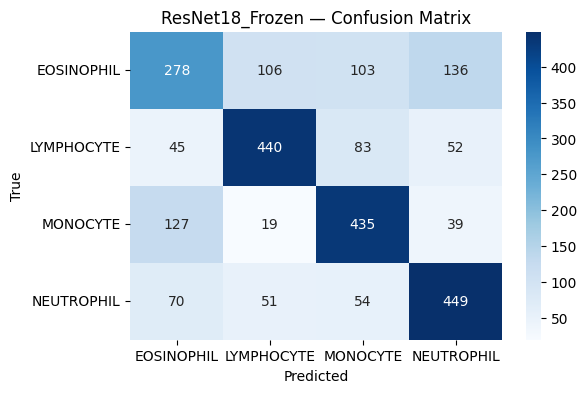

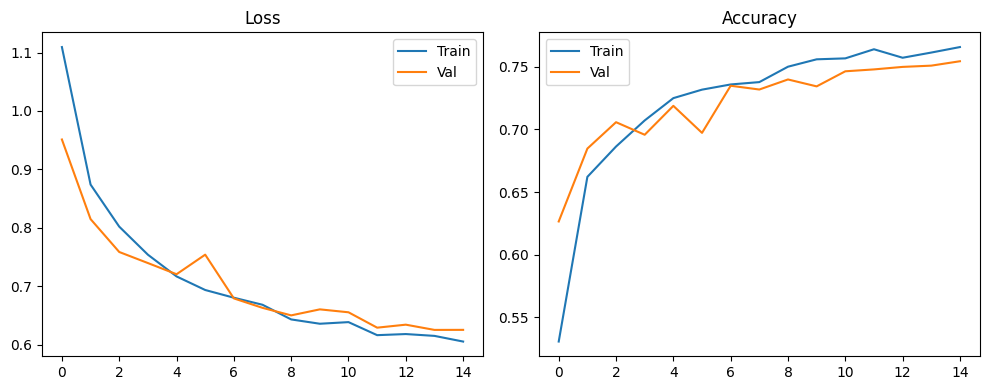

In [ ]:
resnet18_frozen = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # создание модели ResNet18
resnet18_frozen_result = train_frozen_backbone( # обучение модели
    resnet18_frozen, "ResNet18_Frozen", train_loader, val_loader, test_loader,
    epochs=15, lr=1e-3, weight_decay=1e-4
)
torch.save(resnet18_frozen.state_dict(), "outputs/resnet18_frozen.pth") # сохранение модели

Заморозка backbone и обучение только FC-head с weight_decay=1e-4 привела к значительному падению качества: Accuracy 0.6441 против baseline 0.8544 — снижение на ~21%. 

Причина: предобученные признаки ImageNet, будучи «замороженными», не адаптировались к специфике клеток крови. Форма ядра, текстура цитоплазмы и паттерны окрашивания существенно отличаются от ImageNet-объектов, и без fine-tuning backbone линейный классификатор не получает информативных признаков.

Epoch 1/15 | Train Acc: 0.5831 | Val Acc: 0.7239
Epoch 2/15 | Train Acc: 0.7186 | Val Acc: 0.7992
Epoch 3/15 | Train Acc: 0.7542 | Val Acc: 0.8052
Epoch 4/15 | Train Acc: 0.7656 | Val Acc: 0.8293
Epoch 5/15 | Train Acc: 0.7738 | Val Acc: 0.8379
Epoch 6/15 | Train Acc: 0.7827 | Val Acc: 0.8564
Epoch 7/15 | Train Acc: 0.7877 | Val Acc: 0.8469
Epoch 8/15 | Train Acc: 0.7937 | Val Acc: 0.8338
Epoch 9/15 | Train Acc: 0.7967 | Val Acc: 0.8589
Epoch 10/15 | Train Acc: 0.8035 | Val Acc: 0.8630
Epoch 11/15 | Train Acc: 0.8033 | Val Acc: 0.8735
Epoch 12/15 | Train Acc: 0.8075 | Val Acc: 0.8750
Epoch 13/15 | Train Acc: 0.8133 | Val Acc: 0.8810
Epoch 14/15 | Train Acc: 0.8142 | Val Acc: 0.8775
Epoch 15/15 | Train Acc: 0.8195 | Val Acc: 0.8725

=== Swin-T_Frozen — TEST ===
Accuracy: 0.7125 | Balanced Acc: 0.7123 | Macro-F1: 0.7125


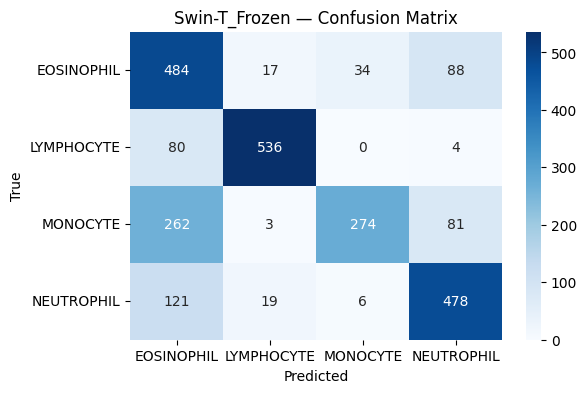

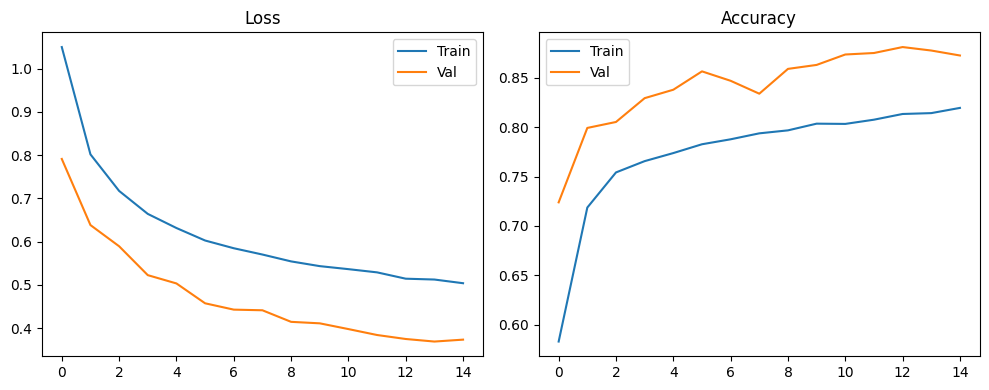

In [ ]:
swin_frozen = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1) # создание модели Swin-T
swin_frozen_result = train_frozen_backbone( # обучение модели
    swin_frozen, "Swin-T_Frozen", train_loader, val_loader, test_loader,
    epochs=15, lr=1e-3, weight_decay=1e-4
)
torch.save(swin_frozen.state_dict(), "outputs/swin_frozen.pth") # сохранение модели

Аналогичная ситуация: Accuracy 0.7125 против 0.8802 — снижение на ~17%. Несмотря на то что Swin-T пострадал меньше ResNet18 (его предобученные признаки более обобщённые благодаря связям), замороженный backbone всё равно не обеспечивает достаточного качества признаков для задачи.

Гипотеза отвергнута для обеих архитектур. Заморозка backbone оправдана лишь при очень малых датасетах (<1–2k) или при наличии риска катастрофического забывания.